In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score

from keras.models import Sequential, Model
from keras.layers import Dense, Activation, Input

c:\Users\DECOMEI\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
COLUMN_SNOW_2M = "snowfall (cm)"

In [4]:
df = pd.read_csv("herford_weather.csv", parse_dates=['time']).set_index('time')
display(df.index.dtype)
df[:5]

dtype('<M8[ns]')

,temperature_2m (°C),relativehumidity_2m (%),dewpoint_2m (°C),apparent_temperature (°C),pressure_msl (hPa),surface_pressure (hPa),precipitation (mm),rain (mm),snowfall (cm),weathercode (wmo code),...,et0_fao_evapotranspiration (mm),vapor_pressure_deficit (kPa),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),soil_temperature_28_to_100cm (°C),soil_temperature_100_to_255cm (°C),soil_moisture_0_to_7cm (m³/m³),soil_moisture_7_to_28cm (m³/m³),soil_moisture_28_to_100cm (m³/m³),soil_moisture_100_to_255cm (m³/m³)
time,,,,,,,,,,,,,,,,,,,,,
1996-01-01 00:00:00,-2.3,80,-5.3,-7.2,1003.4,988.2,0.0,0.0,0.0,3,...,0.01,0.11,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34
1996-01-01 01:00:00,-2.1,80,-5.2,-7.0,1003.8,988.6,0.0,0.0,0.0,3,...,0.01,0.11,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34
1996-01-01 02:00:00,-2.0,79,-5.2,-6.9,1003.9,988.7,0.0,0.0,0.0,3,...,0.01,0.11,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34
1996-01-01 03:00:00,-2.1,79,-5.3,-7.0,1004.0,988.8,0.0,0.0,0.0,3,...,0.01,0.11,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34
1996-01-01 04:00:00,-2.2,78,-5.5,-7.1,1004.5,989.3,0.0,0.0,0.0,3,...,0.01,0.12,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34


snowfall (cm)                        1.000000
weathercode (wmo code)               0.299132
precipitation (mm)                   0.177701
cloudcover_mid (%)                   0.151412
apparent_temperature (°C)            0.145608
temperature_2m (°C)                  0.142825
soil_temperature_7_to_28cm (°C)      0.137320
soil_temperature_0_to_7cm (°C)       0.137279
dewpoint_2m (°C)                     0.131738
soil_temperature_28_to_100cm (°C)    0.121669
Name: snowfall (cm), dtype: float64

<Axes: xlabel='snowfall (cm)', ylabel='None'>

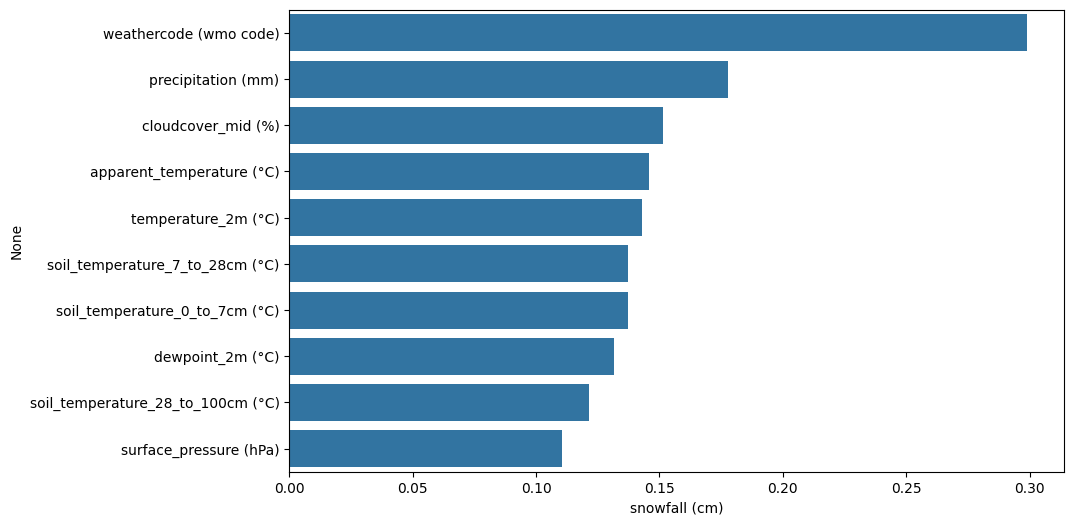

In [5]:
corr_matrix = df.corr()

# abs -> both pos and neg correlation should work
target_corr = corr_matrix[COLUMN_SNOW_2M].abs().sort_values(ascending=False)
display(target_corr[:10]) 

top_features = target_corr.index[1:11]  # [1: ] to remove self

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr[top_features], y=top_features)

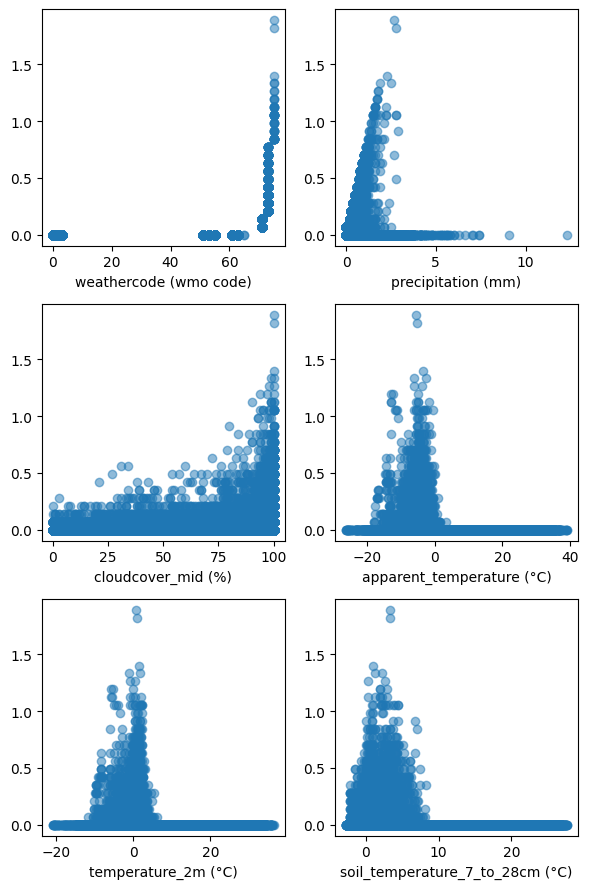

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(6, 9))

for i, feature in enumerate(target_corr.index[1:7]):
    axes.flat[i].scatter(df[feature], df[COLUMN_SNOW_2M], alpha=0.5)
    axes.flat[i].set_xlabel(feature)
plt.tight_layout()
plt.show()


Feature Importance (Random Forest):
precipitation (mm)                    0.707616
rain (mm)                             0.183109
apparent_temperature (°C)             0.057581
temperature_2m (°C)                   0.007206
surface_pressure (hPa)                0.003276
pressure_msl (hPa)                    0.002867
soil_moisture_100_to_255cm (m³/m³)    0.002545
winddirection_100m (°)                0.002539
winddirection_10m (°)                 0.002379
windspeed_100m (km/h)                 0.002317
dtype: float64


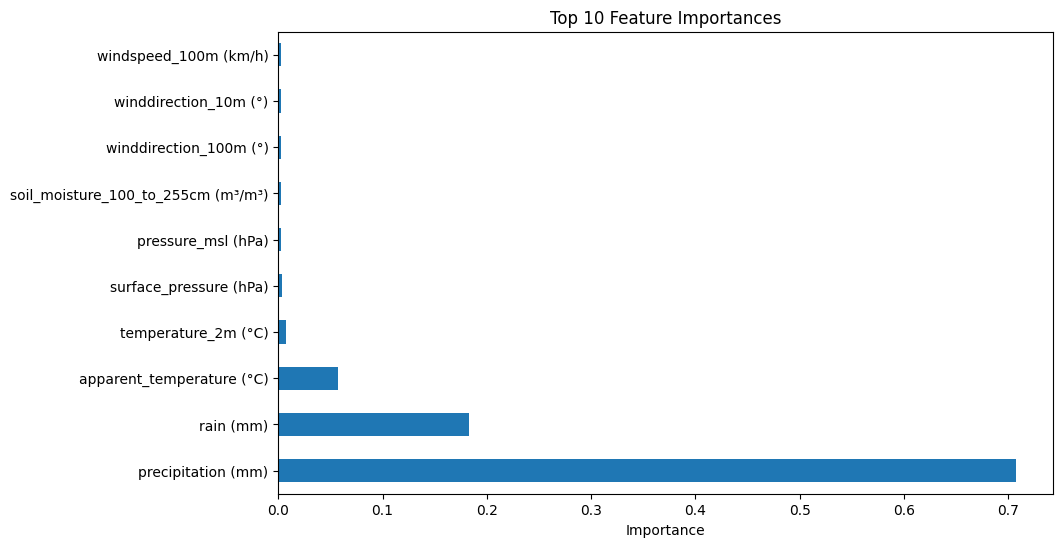

In [16]:
# Weitere Analyse: Feature Importance mit Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Daten vorbereiten (ohne NaN-Werte)
df_clean = df.dropna()
X = df_clean.drop(columns=[COLUMN_SNOW_2M])
y = df_clean[COLUMN_SNOW_2M]

# Train-Test-Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Modell
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Feature Importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importance (Random Forest):")
print(feature_importance.head(10))

# Plot
plt.figure(figsize=(10, 6))
feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.show()

In [ ]:
# Mutual Information für nicht-lineare Beziehungen
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print("\nMutual Information Scores:")
print(mi_scores.head(10))

# Plot
plt.figure(figsize=(10, 6))
mi_scores.head(10).plot(kind='barh')
plt.title("Top 10 Mutual Information Scores")
plt.xlabel("MI Score")
plt.show()

In [ ]:
# Recursive Feature Elimination (RFE) mit Random Forest
from sklearn.feature_selection import RFE

rfe = RFE(estimator=RandomForestRegressor(n_estimators=100, random_state=42), n_features_to_select=10)
rfe.fit(X, y)

selected_features_rfe = X.columns[rfe.support_]
print("\nAusgewählte Merkmale mit RFE:")
print(selected_features_rfe)

# Ranking
ranking = pd.Series(rfe.ranking_, index=X.columns).sort_values()
print("\nRFE Ranking (1 = ausgewählt):")
print(ranking.head(15))

In [ ]:
# LASSO Regression für Feature-Selection
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso = Lasso(alpha=0.01, random_state=42)  # Alpha anpassen für Regularisierung
lasso.fit(X_scaled, y)

lasso_coef = pd.Series(lasso.coef_, index=X.columns).abs().sort_values(ascending=False)
print("\nLASSO Koeffizienten (absolut):")
print(lasso_coef.head(10))

# Merkmale mit nicht-Null-Koeffizienten
selected_lasso = lasso_coef[lasso_coef > 0].index
print(f"\nAusgewählte Merkmale mit LASSO (nicht-Null): {len(selected_lasso)}")
print(selected_lasso)